# Amerikai piacok: forgatókönyv-elemzési projekt

Stratégiai, 20-szoros exposure stackinggel becsült mean-CVaR portfólió, külön Vorobets-stílusú EP/FFR forgatókönyv-tesztekkel.

A notebook fő szabályai:
- **Kitettségekkel** dolgozunk, de mivel long-only portfolioról van szó és a kitettségek összege %-ban nem haladja meg a 100%-ot, ezért hívhatók súlyoknak is. 
- A számítási motorban logváltozásokat / loghozamokat használunk.
- Minden megjelenített eredményhozamot egyszerű hozammá alakítunk vissza, különösen a KDE-ábrákon és az FFR terminális hozamainál.
- A stratégiai portfóliót elkülönítjük a forgatókönyv-feltételezésektől.
- Először minden feltételes változót külön vizsgálunk.
- A fejezet szerinti FFR-logikát követjük: állapotfüggő várható érték- és volatilitási nézetek, EP állapotvalószínűségek, majd állapotfüggő újramintavételezés.
- Olajat és külön S&P 500 állapotot egyelőre nem használunk.

In [18]:
import os
from itertools import product

import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
import fortitudo.tech as ft
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelcolor": "#2f3437",
        "axes.edgecolor": "#d5d8dc",
        "grid.color": "#e7e9ec",
        "grid.linewidth": 0.8,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    },
)
palette = {
    "Alacsony": "#2f6f9f",
    "Közepes": "#8a8f98",
    "Magas": "#b4433c",
    "Normál": "#3d7f5f",
    "Krízis": "#b4433c",
    "Bull": "#2f8f6b",
    "Neutral": "#8a8f98",
    "Bear": "#b4433c",
    "30 éves zérókupon esik / emelkedő hozamnyomás": "#b4433c",
    "30 éves semleges környezet": "#8a8f98",
    "30 éves zérókupon emelkedik / csökkenő hozamtámogatás": "#2f8f6b",
}
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
np.random.seed(7)

figure_dir = "overleaf_figures"
os.makedirs(figure_dir, exist_ok=True)

def save_figure(fig, name):
    png_path = os.path.join(figure_dir, f"{name}.png")
    pdf_path = os.path.join(figure_dir, f"{name}.pdf")
    fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    print(f"Mentve: {png_path}")
    print(f"Mentve: {pdf_path}")


## 1. Projektparaméterek

Ezek szándékosan szabadon állítható paraméterek. Először ezeket módosítsd, majd futtasd újra a notebookot.

In [19]:
assets = {
    "US broad equity": "VOO",
    "Nasdaq 100": "QQQ",
    "Gold": "GLD",
    "Spain": "EWP",
    "Poland / Eastern Europe proxy": "EPOL",
    "Feltörekvő piacok Kína nélkül": "EMXC",
    "Latin America": "ILF",
}

state_tickers = {
    "VIX": "^VIX",
    "VIX 3M": "^VIX3M",
}

fred_series = {
    "Amerikai 30 éves hozam": "DGS30",
}

# Keep the key outside the notebook file, e.g. in the shell before launching Jupyter:
# export FRED_API_KEY="..."
fred_api_key = os.getenv("FRED_API_KEY")

# EMXC constrains the common live history to mid-2017.
start = "2017-07-18"

# Stratégiai optimalizációs paraméterek. Iterálás közben érdemes a num_bootstraps értékét mérsékelten tartani.
num_bootstraps = 200
sample_size_days = 756
num_frontier_portfolios = 9
frontier_index = 4
stacking_folds = 20
alpha = 0.95
# Long-only portfólió, eszközönként legfeljebb 20% kitettséggel.
max_exposure = 0.20

# FFR-paraméterek.
ffr_num_paths = 10000
ffr_horizons = [21, 126]
state_half_life_fraction = 0.5

## 2. Adatkezelő segédfüggvények

In [20]:
def download_yahoo_prices(ticker_map, start):
    tickers = list(ticker_map.values())
    raw = yf.download(tickers, start=start, auto_adjust=False, progress=False)
    field = "Adj Close" if isinstance(raw.columns, pd.MultiIndex) and "Adj Close" in raw.columns.get_level_values(0) else "Close"
    prices = raw[field] if isinstance(raw.columns, pd.MultiIndex) else raw
    prices = prices.rename(columns={v: k for k, v in ticker_map.items()})
    prices = prices.sort_index().ffill().dropna(how="all")
    return prices


def load_fred_series(series_id, name, start, api_key=None):
    if api_key:
        url = "https://api.stlouisfed.org/fred/series/observations"
        params = {
            "series_id": series_id,
            "api_key": api_key,
            "file_type": "json",
            "observation_start": start,
        }
        payload = pd.read_json(url + "?" + "&".join(f"{k}={v}" for k, v in params.items()))
        df = pd.DataFrame(payload.loc["observations", 0])
        df = df.rename(columns={"value": name})
        df["date"] = pd.to_datetime(df["date"])
        df = df.set_index("date")[[name]]
    else:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
        df = pd.read_csv(url, parse_dates=["observation_date"])
        df = df.rename(columns={"observation_date": "date", series_id: name}).set_index("date")
        df = df.loc[start:]
    df[name] = pd.to_numeric(df[name].replace(".", np.nan), errors="coerce")
    return df.ffill().dropna()


def log_returns(prices):
    clean = prices[prices > 0].dropna(axis=0, how="any")
    pnl = np.diff(np.log(clean.values), axis=0)
    return pd.DataFrame(pnl, index=clean.index[1:], columns=clean.columns)


def log_to_simple_return(log_return):
    return np.exp(log_return) - 1


def cumulative_log_to_simple_return(log_returns):
    return np.exp(np.cumsum(log_returns, axis=1))[:, -1] - 1


def exposure_constraints(num_eszköz, max_exposure=1.0):
    G = np.vstack((-np.eye(num_eszköz), np.eye(num_eszköz)))
    h = np.hstack((np.zeros(num_eszköz), max_exposure * np.ones(num_eszköz)))
    A = np.ones((1, num_eszköz))
    b = np.ones(1)
    return G, h, A, b


def show_data_summary(prices, pnl):
    print(f"Megtalált eszközök: {prices.shape[1]} / {len(assets)}")
    print(f"Árfolyam-megfigyelések: {len(prices)} ({len(prices) / 252:,.2f} kereskedési év, közelítőleg)")
    print(f"Időszak: {prices.index[0].date()} -> {prices.index[-1].date()}")
    print(f"Hozamok: {pnl.shape[0]} nap x {pnl.shape[1]} eszköz")
    return np.round(ft.simulation_moments(pnl), 4)

## 3. Eszközadatok

In [21]:
asset_prices = download_yahoo_prices(assets, start=start)
asset_pnl = log_returns(asset_prices)
show_data_summary(asset_prices, asset_pnl)

Megtalált eszközök: 7 / 7
Árfolyam-megfigyelések: 2224 (8.83 kereskedési év, közelítőleg)
Időszak: 2017-07-18 -> 2026-05-21
Hozamok: 2217 nap x 7 eszköz


,Mean,Volatility,Skewness,Kurtosis
Ticker,,,,
Feltörekvő piacok Kína nélkül,0.0004,0.0125,-1.3332,19.6255
Poland / Eastern Europe proxy,0.0003,0.0178,-0.2636,8.0340
Spain,0.0004,0.0140,-1.2822,19.6912
Gold,0.0006,0.0103,-0.7749,11.7968
Latin America,0.0002,0.0182,-1.1747,17.1567
Nasdaq 100,0.0007,0.0147,-0.3716,10.2559
US broad equity,0.0006,0.0119,-0.6555,18.4144


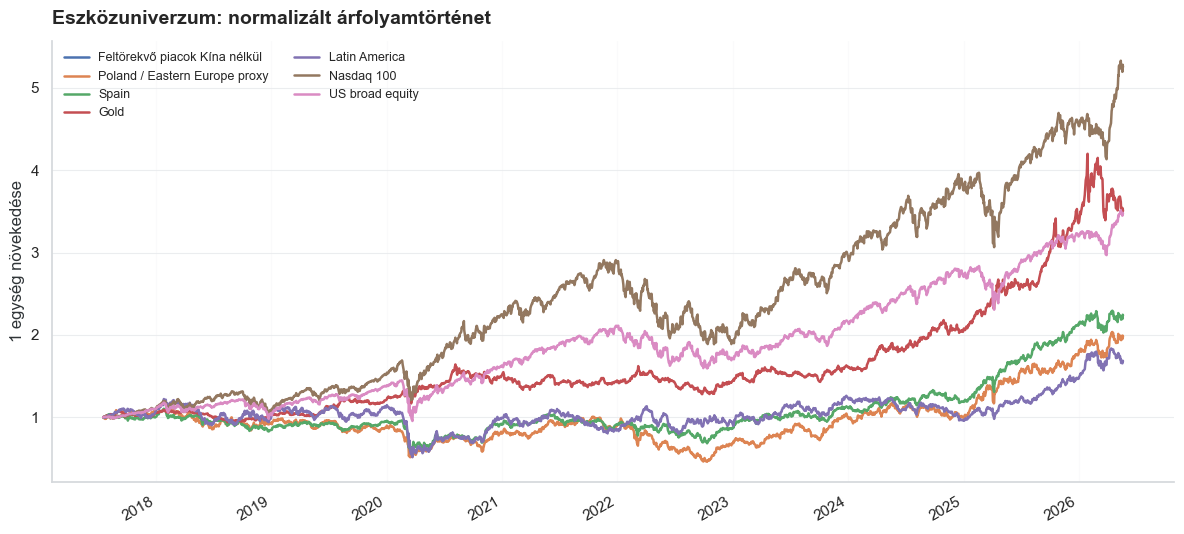

In [22]:
fig, ax = plt.subplots(figsize=(12, 5.5))
asset_prices.divide(asset_prices.iloc[0]).plot(ax=ax, linewidth=1.8)
ax.set_title("Eszközuniverzum: normalizált árfolyamtörténet", loc="left", fontsize=14, pad=12)
ax.set_ylabel("1 egység növekedése")
ax.set_xlabel("")
ax.legend(frameon=False, ncol=2, fontsize=9)
ax.grid(axis="y", alpha=0.8)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 4. Állapotváltozók és gyors ellenőrző ábra

Az EP/FFR előtt ellenőrizzük a nyers állapotváltozókat. A 30 éves hozam esetében az FFR nem a nyers hozamszintet, hanem a 30 éves zérókupon-kötvény stacionárius logváltozását használja.

In [23]:
state_prices = download_yahoo_prices(state_tickers, start=start)
yield_30y = load_fred_series(fred_series["Amerikai 30 éves hozam"], "Amerikai 30 éves hozam", start=start, api_key=fred_api_key)

state_raw = state_prices.join(yield_30y, how="outer").ffill().dropna()
state_raw["VIX term"] = state_raw["VIX"] - state_raw["VIX 3M"]
state_raw["Amerikai 30 éves zérókupon"] = np.exp(-state_raw["Amerikai 30 éves hozam"] / 100 * 30)
state_raw["Amerikai 30 éves zérókupon logváltozás"] = np.log(state_raw["Amerikai 30 éves zérókupon"]).diff()
state_raw = state_raw.dropna()

state_raw.tail()

,VIX,VIX 3M,Amerikai 30 éves hozam,VIX term,Amerikai 30 éves zérókupon,Amerikai 30 éves zérókupon logváltozás
Date,,,,,,
2026-05-15,18.4300,21.3600,5.1200,-2.9300,0.2152,-0.0300
2026-05-18,17.8200,20.9200,5.1400,-3.1000,0.2140,-0.0060
2026-05-19,18.0600,21.1200,5.1800,-3.0600,0.2114,-0.0120
2026-05-20,17.4400,20.7600,5.1800,-3.3200,0.2114,0.0000
2026-05-21,17.6900,20.8200,5.1800,-3.1300,0.2114,0.0000


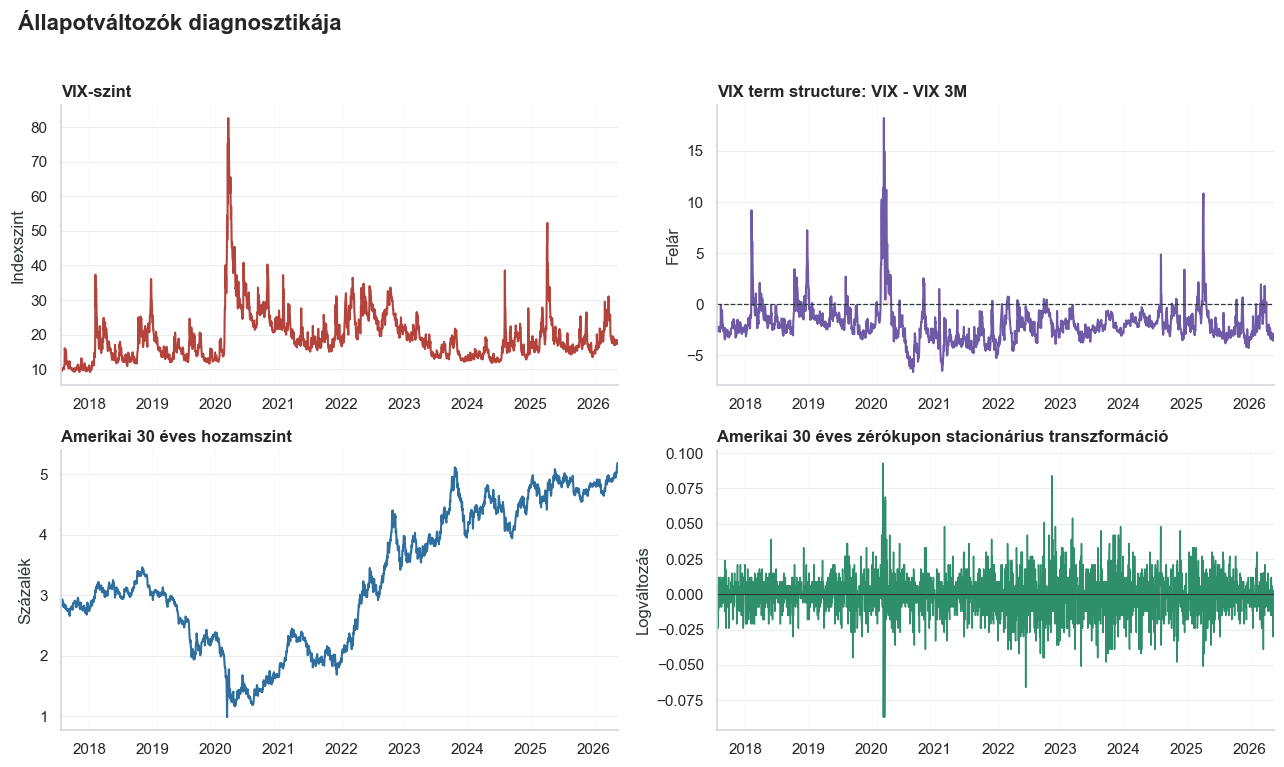

In [24]:
fig, ax = plt.subplots(2, 2, figsize=(13, 7.5))
fig.suptitle("Állapotváltozók diagnosztikája", x=0.02, y=1.02, ha="left", fontsize=16, fontweight="bold")

state_raw["VIX"].plot(ax=ax[0, 0], color="#b4433c", linewidth=1.5)
ax[0, 0].set_title("VIX-szint", loc="left")
ax[0, 0].set_ylabel("Indexszint")

state_raw["VIX term"].plot(ax=ax[0, 1], color="#6f5aa7", linewidth=1.5)
ax[0, 1].axhline(0, color="#2f3437", linewidth=0.9, linestyle="--")
ax[0, 1].fill_between(state_raw.index, 0, state_raw["VIX term"], where=state_raw["VIX term"] > 0, color="#b4433c", alpha=0.12)
ax[0, 1].set_title("VIX term structure: VIX - VIX 3M", loc="left")
ax[0, 1].set_ylabel("Felár")

state_raw["Amerikai 30 éves hozam"].plot(ax=ax[1, 0], color="#2f6f9f", linewidth=1.5)
ax[1, 0].set_title("Amerikai 30 éves hozamszint", loc="left")
ax[1, 0].set_ylabel("Százalék")

state_raw["Amerikai 30 éves zérókupon logváltozás"].plot(ax=ax[1, 1], color="#2f8f6b", linewidth=1.1)
ax[1, 1].axhline(0, color="#2f3437", linewidth=0.8)
ax[1, 1].set_title("Amerikai 30 éves zérókupon stacionárius transzformáció", loc="left")
ax[1, 1].set_ylabel("Logváltozás")

for axis in ax.ravel():
    axis.set_xlabel("")
    axis.grid(axis="y", alpha=0.8)
    axis.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Piaci esetek meghatározása

Egyszerű, ügyfélbarát áttekintés arról, hogyan definiáljuk a piaci eseteket: az idei év három fő bizonytalansági forrásából Bull, Neutral és Bear eseteket képzünk, majd ezek portfólióhatását vizsgáljuk.

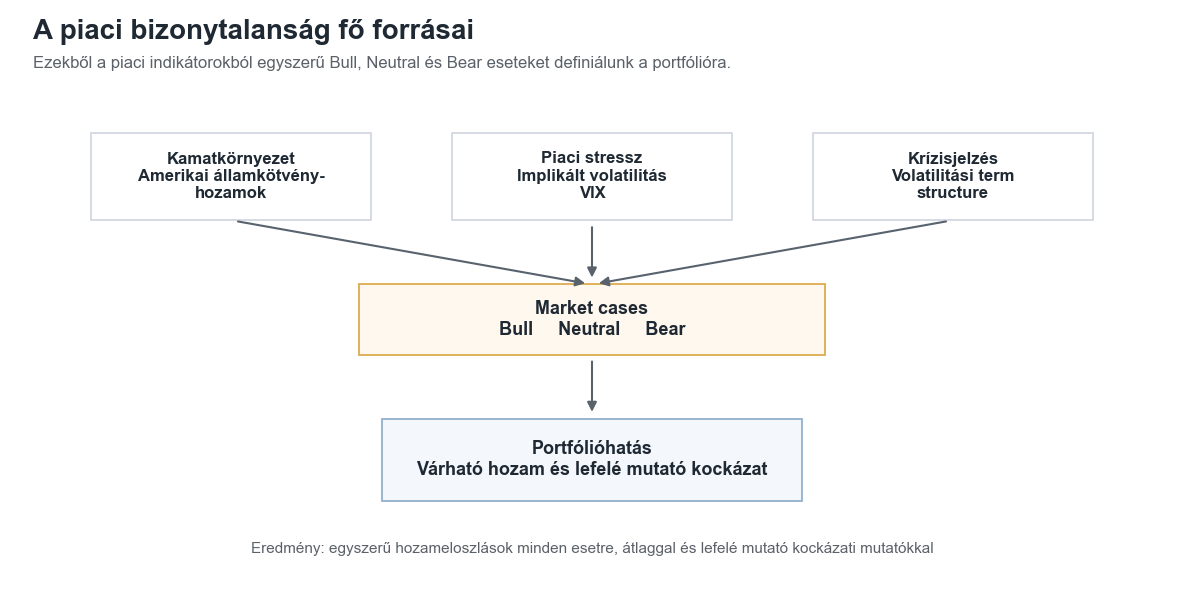

In [25]:
def draw_market_case_diagram():
    fig, ax = plt.subplots(figsize=(12, 6.2))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    def box(x, y, w, h, text, facecolor, edgecolor="#d5d8dc", fontsize=12, weight="normal"):
        patch = plt.Rectangle((x, y), w, h, facecolor=facecolor, edgecolor=edgecolor, linewidth=1.2)
        ax.add_patch(patch)
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize, fontweight=weight, color="#1f2933")
        return patch

    ax.text(0.02, 0.95, "A piaci bizonytalanság fő forrásai", fontsize=20, fontweight="bold", ha="left", color="#1f2933")
    ax.text(0.02, 0.90, "Ezekből a piaci indikátorokból egyszerű Bull, Neutral és Bear eseteket definiálunk a portfólióra.", fontsize=12, ha="left", color="#5b6168")

    drivers = [
        (0.07, 0.64, "Kamatkörnyezet", "Amerikai államkötvény-\nhozamok"),
        (0.38, 0.64, "Piaci stressz", "Implikált volatilitás\nVIX"),
        (0.69, 0.64, "Krízisjelzés", "Volatilitási term\nstructure"),
    ]
    for x, y, title, subtitle in drivers:
        box(x, y, 0.24, 0.15, f"{title}\n{subtitle}", "#ffffff", edgecolor="#cfd6df", fontsize=12, weight="bold")

    box(0.30, 0.41, 0.40, 0.12, "Market cases\nBull     Neutral     Bear", "#fff8ef", edgecolor="#d9a441", fontsize=13, weight="bold")
    box(0.32, 0.16, 0.36, 0.14, "Portfólióhatás\nVárható hozam és lefelé mutató kockázat", "#f4f7fb", edgecolor="#8aa9c7", fontsize=13, weight="bold")

    arrowprops = dict(arrowstyle="-|>", color="#59636e", linewidth=1.5, shrinkA=5, shrinkB=5, mutation_scale=14)
    for x, _, _, _ in drivers:
        ax.annotate("", xy=(0.50, 0.53), xytext=(x + 0.12, 0.64), arrowprops=arrowprops)
    ax.annotate("", xy=(0.50, 0.30), xytext=(0.50, 0.41), arrowprops=arrowprops)

    ax.text(0.50, 0.07, "Eredmény: egyszerű hozameloszlások minden esetre, átlaggal és lefelé mutató kockázati mutatókkal", ha="center", fontsize=11, color="#5b6168")
    plt.tight_layout()
    save_figure(fig, "01_piaci_esetek_logika")
    plt.show()


draw_market_case_diagram()

## 6. Stratégiai portfólió: 20-szoros stacked mean-CVaR

In [26]:
def stacked_mean_cvar_portfolio(R, num_bootstraps, sample_size_days, num_frontier_portfolios, frontier_index, stacking_folds):
    T, I = R.shape
    sample_size = min(sample_size_days, T)
    G, h, A, b = exposure_constraints(I, max_exposure=max_exposure)
    sample_portfolios = np.full((I, num_bootstraps), np.nan)

    for bootstrap in range(num_bootstraps):
        sample_index = np.random.choice(T, size=sample_size, replace=True)
        R_sample = R.iloc[sample_index].values
        opt = ft.MeanCVaR(R_sample, G=G, h=h, A=A, b=b, alpha=alpha)
        frontier = opt.efficient_frontier(num_frontier_portfolios)
        sample_portfolios[:, bootstrap] = frontier[:, frontier_index]

    exposure = ft.exposure_stacking(stacking_folds, sample_portfolios)
    return pd.Series(exposure, index=R.columns, name="Stratégiai kitettség"), pd.DataFrame(sample_portfolios, index=R.columns)


strategic_exposure, bootstrap_exposures = stacked_mean_cvar_portfolio(
    asset_pnl,
    num_bootstraps=num_bootstraps,
    sample_size_days=sample_size_days,
    num_frontier_portfolios=num_frontier_portfolios,
    frontier_index=frontier_index,
    stacking_folds=stacking_folds,
)

exposure_display = pd.DataFrame({"Stratégiai kitettség": strategic_exposure})
np.round(100 * exposure_display, 2)

,Stratégiai kitettség
Ticker,
Feltörekvő piacok Kína nélkül,17.5900
Poland / Eastern Europe proxy,5.8300
Spain,17.1400
Gold,19.5600
Latin America,3.5700
Nasdaq 100,16.5800
US broad equity,19.7400


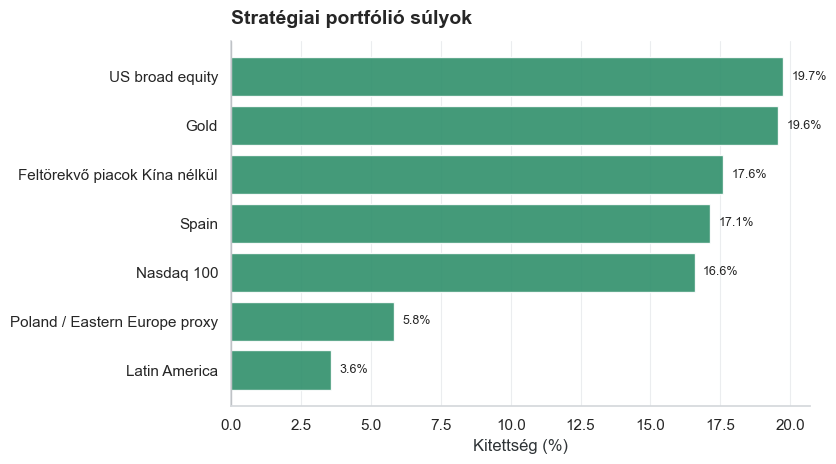

In [27]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot_exposure = strategic_exposure.sort_values()
colors = ["#2f8f6b" if value >= 0 else "#b4433c" for value in plot_exposure]
plot_labels = [f"{name} ({assets[name]})" for name in plot_exposure.index]
ax.barh(plot_labels, 100 * plot_exposure.values, color=colors, alpha=0.9)
ax.set_title("Stratégiai portfólió súlyok", loc="left", fontsize=14, pad=12)
ax.set_xlabel("Kitettség (%)")
ax.axvline(0, color="#2f3437", linewidth=0.8)
for i, value in enumerate(plot_exposure.values):
    ax.text(100 * value + 0.3, i, f"{100 * value:.1f}%", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.8)
ax.grid(axis="y", alpha=0)
plt.tight_layout()
save_figure(fig, "02_strategiai_portfolio_sulyok")
plt.show()

strategic_pnl = asset_pnl @ strategic_exposure
strategic_pnl.name = "Stratégiai portfólió loghozama"

### Stratégiai kitettségek: eszközök és régiók

A következő ábrák ügyfélbarát módon mutatják a stratégiai portfólió eszköz- és földrajzi megoszlását.


In [ ]:
market_segment_map = {
    "Amerikai részvénypiac": "Fejlett piacok",
    "Nasdaq 100": "Fejlett piacok",
    "Spanyolország": "Fejlett piacok",
    "Lengyelország / kelet-európai proxy": "Fejlett piacok",
    "Feltörekvő piacok Kína nélkül": "Feltörekvő piacok",
    "Latin-Amerika": "Feltörekvő piacok",
    "Arany": "Egyéb",
}

region_map = {
    "Amerikai részvénypiac": "USA",
    "Nasdaq 100": "USA",
    "Spanyolország": "Európa",
    "Lengyelország / kelet-európai proxy": "Európa",
    "Feltörekvő piacok Kína nélkül": "Feltörekvő piacok",
    "Latin-Amerika": "Latin-Amerika",
    "Arany": "Arany / reáleszköz",
}

# Color logic: every asset uses a distinguishable shade of its parent category.
asset_color_map = {
    "Amerikai részvénypiac": "#3f668b",
    "Nasdaq 100": "#5c82a8",
    "Spanyolország": "#7da0c2",
    "Lengyelország / kelet-európai proxy": "#a7bed6",
    "Feltörekvő piacok Kína nélkül": "#1f6f56",
    "Latin-Amerika": "#3a9b7a",
    "Arany": "#d9a441",
}
segment_color_map = {
    "Fejlett piacok": "#4f759b",
    "Feltörekvő piacok": "#1f6f56",
    "Egyéb": "#b88619",
}


# Robust aliases in case strategic_exposure was created before rerunning the Hungarian asset-name cell.
asset_name_alias = {
    "US broad equity": "Amerikai részvénypiac",
    "Gold": "Arany",
    "Spain": "Spanyolország",
    "Poland / Eastern Europe proxy": "Lengyelország / kelet-európai proxy",
    "Emerging markets ex China": "Feltörekvő piacok Kína nélkül",
    "Latin America": "Latin-Amerika",
}

def canonical_asset_name(name):
    return asset_name_alias.get(name, name)

def asset_ticker(name):
    canonical = canonical_asset_name(name)
    return assets.get(canonical, assets.get(name, ""))

asset_allocation = strategic_exposure.copy().sort_values(ascending=False)
asset_labels = [f"{canonical_asset_name(name)} ({asset_ticker(name)})" for name in asset_allocation.index]
asset_colors = [asset_color_map[canonical_asset_name(name)] for name in asset_allocation.index]

segment_order = ["Fejlett piacok", "Feltörekvő piacok", "Egyéb"]
segment_allocation = pd.Series({
    segment: asset_allocation[[name for name in asset_allocation.index if market_segment_map[canonical_asset_name(name)] == segment]].sum()
    for segment in segment_order
})
segment_allocation = segment_allocation[segment_allocation > 0]

inner_order = []
for segment in segment_allocation.index:
    names = [name for name in asset_allocation.index if market_segment_map[canonical_asset_name(name)] == segment]
    inner_order.extend(sorted(names, key=lambda name: asset_allocation[name], reverse=True))
inner_values = asset_allocation[inner_order]
inner_labels = [f"{region_map[canonical_asset_name(name)]} ({asset_ticker(name)}): {100 * asset_allocation[name]:.1f}%" for name in inner_order]
inner_colors = [asset_color_map[canonical_asset_name(name)] for name in inner_order]

allocation_colors = asset_colors

fig, ax = plt.subplots(figsize=(12.8, 7.6))
fig.suptitle("Stratégiai portfólió allokáció", x=0.04, y=0.98, ha="left", fontsize=18, fontweight="bold")

def autopct_threshold(values, threshold=3.0):
    def _format(pct):
        return f"{pct:.1f}%" if pct >= threshold else ""
    return _format

outer_wedges, _, outer_texts = ax.pie(
    segment_allocation.values,
    radius=1.0,
    labels=None,
    autopct=autopct_threshold(segment_allocation.values),
    startangle=90,
    counterclock=False,
    colors=[segment_color_map[name] for name in segment_allocation.index],
    wedgeprops={"width": 0.28, "edgecolor": "white", "linewidth": 1.5},
    pctdistance=0.86,
)
inner_wedges, _, inner_texts = ax.pie(
    inner_values.values,
    radius=0.70,
    labels=None,
    autopct=autopct_threshold(inner_values.values, threshold=4.0),
    startangle=90,
    counterclock=False,
    colors=inner_colors,
    wedgeprops={"width": 0.30, "edgecolor": "white", "linewidth": 1.2},
    pctdistance=0.76,
)
ax.set_title("Fejlett / feltörekvő / egyéb és mögöttes eszközök", fontsize=15, fontweight="bold", pad=14)
ax.text(0, 0, "100%", ha="center", va="center", fontsize=16, fontweight="bold", color="#1f2933")

for text_obj in list(outer_texts) + list(inner_texts):
    text_obj.set_color("white")
    text_obj.set_fontsize(10)
    text_obj.set_fontweight("bold")

legend_rows = []
for segment in segment_allocation.index:
    legend_rows.append((segment, f"{100 * segment_allocation[segment]:.1f}%", segment_color_map[segment], "bold"))
    segment_assets = [name for name in inner_order if market_segment_map[canonical_asset_name(name)] == segment]
    for name in segment_assets:
        canonical = canonical_asset_name(name)
        legend_rows.append((f"  {region_map[canonical]} ({asset_ticker(name)})", f"{100 * asset_allocation[name]:.1f}%", asset_color_map[canonical], "normal"))

x0 = 1.15
header_y = 0.93
row_step = 0.078
ax.text(x0, header_y + 0.085, "Allokációs logika", transform=ax.transAxes, fontsize=14, fontweight="bold", color="#1f2933", ha="left", va="center")
ax.text(x0, header_y + 0.035, "Kategória / eszköz", transform=ax.transAxes, fontsize=10.5, fontweight="bold", color="#5b6168", ha="left", va="center")
ax.text(x0 + 0.56, header_y + 0.035, "Súly", transform=ax.transAxes, fontsize=10.5, fontweight="bold", color="#5b6168", ha="right", va="center")

for row_idx, (label, value, color, weight) in enumerate(legend_rows):
    y = header_y - row_idx * row_step
    marker_size = 0.022 if weight == "bold" else 0.016
    ax.add_patch(plt.Rectangle((x0, y - marker_size / 2), marker_size, marker_size, transform=ax.transAxes, facecolor=color, edgecolor="none", clip_on=False))
    ax.text(x0 + 0.036, y, label, transform=ax.transAxes, fontsize=10.8 if weight == "bold" else 10.0, fontweight=weight, color="#1f2933", ha="left", va="center")
    ax.text(x0 + 0.56, y, value, transform=ax.transAxes, fontsize=10.8 if weight == "bold" else 10.0, fontweight=weight, color="#1f2933", ha="right", va="center")

plt.tight_layout(rect=[0, 0, 0.72, 0.94])
save_figure(fig, "03_strategiai_portfolio_allokacio")
plt.show()

print(f"Összes stratégiai kitettség: {100 * strategic_exposure.sum():.4f}%")


## 7. Vorobets-stílusú EP/FFR segédfüggvények

Ez a fejezet logikáját követi: történelmi állapotok definiálása, állapotfüggő várható érték- és volatilitási nézetek számítása, EP állapotvalószínűségek meghatározása, majd állapotfüggő történelmi újramintavételezés.

In [28]:
def quantile_state_masks(x, low_q=0.25, high_q=0.75):
    low = x <= np.quantile(x, low_q)
    high = x > np.quantile(x, high_q)
    mid = ~(low | high)
    return {
        "Alacsony": low,
        "Közepes": mid,
        "Magas": high,
    }


def binary_state_masks(x, threshold=0.0, normal_label="Normál", crisis_label="Krízis"):
    return {
        normal_label: x <= threshold,
        crisis_label: x > threshold,
    }


def ep_state_probabilities(state_variable, masks, half_life_fraction=0.5):
    x = np.asarray(state_variable).reshape(-1)
    T_tilde = len(x)
    p_exp = ft.exp_decay_probs(x[:, np.newaxis], half_life=max(1, int(T_tilde * half_life_fraction)))

    A = np.vstack((np.ones((1, T_tilde)), x[np.newaxis]))
    G = x[np.newaxis] ** 2

    state_prob = []
    state_labels = []
    states_vector = np.full(T_tilde, -1, dtype=int)

    for state_index, (label, mask) in enumerate(masks.items()):
        if np.sum(mask) < 5:
            raise ValueError(f"Állapot '{label}' has too few observations: {np.sum(mask)}")
        mu = np.mean(x[mask])
        sigma = np.std(x[mask])
        b = np.array([[1.0], [mu]])
        h = np.array([[sigma**2 + mu**2]])
        q = ft.entropy_pooling(p_exp, A, b, G, h)
        state_prob.append((q / np.sum(q))[:, 0])
        state_labels.append(label)
        states_vector[mask] = state_index

    if np.any(states_vector < 0):
        raise ValueError("Néhány megfigyeléshez nem tartozik állapot.")

    return np.vstack(state_prob).T, states_vector, state_labels


def resampling_indices(num_paths, horizon, initial_state, state_prob, states_vector):
    sim = np.full((num_paths, horizon), -1, dtype=int)
    historical_indices = np.arange(len(states_vector))
    for path in range(num_paths):
        current_state = initial_state
        for step in range(horizon):
            idx = np.random.choice(historical_indices, p=state_prob[:, current_state])
            sim[path, step] = idx
            current_state = states_vector[idx]
    return sim


def terminal_returns_by_state(portfolio_log_returns, state_variable, masks, horizon, num_paths):
    aligned = pd.concat([portfolio_log_returns, state_variable.rename("state")], axis=1).dropna()
    pf = aligned.iloc[:, 0].values
    x = aligned["state"].values
    local_masks = {label: np.asarray(mask.loc[aligned.index] if isinstance(mask, pd.Series) else mask[-len(aligned):]) for label, mask in masks.items()}
    state_prob, states_vector, state_labels = ep_state_probabilities(x, local_masks, state_half_life_fraction)

    terminal = {}
    for initial_state, label in enumerate(state_labels):
        sim_idx = resampling_indices(num_paths, horizon, initial_state, state_prob, states_vector)
        terminal[label] = cumulative_log_to_simple_return(pf[sim_idx])
    return terminal, state_prob, states_vector, state_labels


def ep_joint_state_probabilities(state_variables, masks, half_life_fraction=0.5):
    X = np.asarray(state_variables)
    T_tilde, num_vars = X.shape
    p_exp = ft.exp_decay_probs(X, half_life=max(1, int(T_tilde * half_life_fraction)))

    A = np.vstack((np.ones((1, T_tilde)), X.T))
    G = (X.T) ** 2

    state_prob = []
    state_labels = []
    states_vector = np.full(T_tilde, -1, dtype=int)

    for state_index, (label, mask) in enumerate(masks.items()):
        mask = np.asarray(mask)
        if np.sum(mask) < 5:
            raise ValueError(f"A(z) '{label}' együttes állapothoz túl kevés megfigyelés tartozik: {np.sum(mask)}")
        mu = np.mean(X[mask, :], axis=0)
        sigma = np.std(X[mask, :], axis=0)
        b = np.vstack(([[1.0]], mu[:, np.newaxis]))
        h = (sigma**2 + mu**2)[:, np.newaxis]
        q = ft.entropy_pooling(p_exp, A, b, G, h)
        state_prob.append((q / np.sum(q))[:, 0])
        state_labels.append(label)
        states_vector[mask] = state_index

    if np.any(states_vector < 0):
        raise ValueError("Néhány megfigyeléshez nem tartozik együttes állapot.")

    return np.vstack(state_prob).T, states_vector, state_labels


def terminal_returns_by_joint_state(portfolio_log_returns, state_df, masks, horizon, num_paths, labels_to_plot=None):
    aligned = pd.concat([portfolio_log_returns, state_df], axis=1).dropna()
    pf = aligned.iloc[:, 0].values
    X = aligned.iloc[:, 1:].values
    local_masks = {label: np.asarray(mask.loc[aligned.index]) for label, mask in masks.items()}

    state_prob, states_vector, state_labels = ep_joint_state_probabilities(X, local_masks, state_half_life_fraction)
    labels_to_plot = state_labels if labels_to_plot is None else labels_to_plot

    terminal = {}
    for initial_state, label in enumerate(state_labels):
        sim_idx = resampling_indices(num_paths, horizon, initial_state, state_prob, states_vector)
        if label in labels_to_plot:
            terminal[label] = cumulative_log_to_simple_return(pf[sim_idx])
    return terminal, state_prob, states_vector, state_labels


def plot_terminal_kde(terminal, title, save_name=None):
    fig, ax = plt.subplots(figsize=(9, 5.2))
    for label, values in terminal.items():
        color = palette.get(label, None)
        sns.kdeplot(100 * values, label=label, ax=ax, linewidth=2.2, color=color, fill=False)
        mean_value = 100 * np.mean(values)
        ax.axvline(mean_value, color=color, linewidth=1.0, linestyle=":", alpha=0.8)
    ax.axvline(0, color="#2f3437", linewidth=0.9, linestyle="--", alpha=0.8)
    ax.set_title(title, loc="left", fontsize=14, pad=12)
    ax.set_xlabel("Terminális egyszerű hozam (%)")
    ax.set_ylabel("Sűrűség")
    ax.legend(frameon=False, title="Állapot")
    ax.grid(axis="y", alpha=0.8)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


def ep_diagnostics_table(state_prob, state_labels, states_vector):
    T_tilde = state_prob.shape[0]
    p = np.ones((T_tilde, 1)) / T_tilde
    rows = []
    for state_index, label in enumerate(state_labels):
        q = state_prob[:, state_index][:, np.newaxis]
        positive = q[:, 0] > 0
        re = np.sum(q[positive, 0] * (np.log(q[positive, 0]) - np.log(p[positive, 0])))
        ens = float(np.exp(-re) * T_tilde)
        rows.append({
            "Állapot": label,
            "Megfigyelések": int(np.sum(states_vector == state_index)),
            "Relatív entrópia": re,
            "Effektív forgatókönyvek": ens,
            "Effektív forgatókönyvek %": ens / T_tilde,
        })
    return pd.DataFrame(rows).set_index("Állapot")


def terminal_summary_table(terminal, alpha=0.95):
    rows = []
    for label, values in terminal.items():
        losses = -np.asarray(values)
        var = np.quantile(losses, alpha)
        cvar = losses[losses >= var].mean()
        rows.append({
            "Állapot": label,
            "Átlaghozam %": 100 * np.mean(values),
            "Volatilitás %": 100 * np.std(values),
            "VaR veszteség %": 100 * var,
            "CVaR veszteség %": 100 * cvar,
        })
    return pd.DataFrame(rows).set_index("Állapot")


def display_ffr_diagnostics(title, terminal, state_prob, state_labels, states_vector):
    print(title)
    print("EP-diagnosztika")
    display(np.round(ep_diagnostics_table(state_prob, state_labels, states_vector), 4))
    print("Terminális egyszerűhozam-diagnosztika")
    display(np.round(terminal_summary_table(terminal, alpha=alpha), 4))

## 8. Külön FFR-teszt: VIX alacsony / közepes / magas

VIX-állapotok, H=21
EP-diagnosztika


,Megfigyelések,Relatív entrópia,Effektív forgatókönyvek,Effektív forgatókönyvek %
Állapot,,,,
Alacsony,555,1.3028,602.5197,0.2718
Közepes,1108,0.6109,"1,203.5131",0.5429
Magas,554,0.9434,863.0429,0.3893


Terminális egyszerűhozam-diagnosztika


,Átlaghozam %,Volatilitás %,VaR veszteség %,CVaR veszteség %
Állapot,,,,
Alacsony,2.8282,3.2196,2.4092,4.5492
Közepes,2.2129,3.9682,4.3495,6.8774
Magas,0.8633,5.1543,8.0883,11.1036


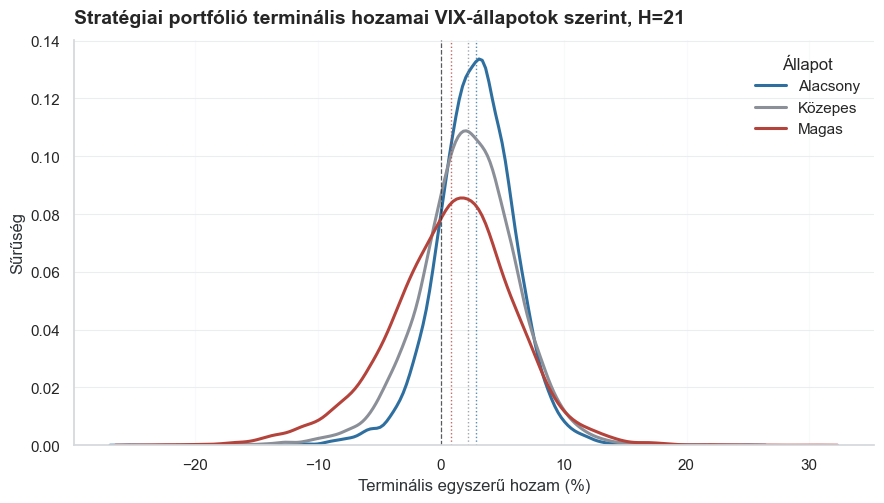

VIX-állapotok, H=126
EP-diagnosztika


,Megfigyelések,Relatív entrópia,Effektív forgatókönyvek,Effektív forgatókönyvek %
Állapot,,,,
Alacsony,555,1.3028,602.5197,0.2718
Közepes,1108,0.6109,"1,203.5131",0.5429
Magas,554,0.9434,863.0429,0.3893


Terminális egyszerűhozam-diagnosztika


,Átlaghozam %,Volatilitás %,VaR veszteség %,CVaR veszteség %
Állapot,,,,
Alacsony,15.4897,10.4014,1.5968,6.2193
Közepes,14.8338,10.6154,2.6794,7.6997
Magas,13.4057,11.4086,5.1523,10.3008


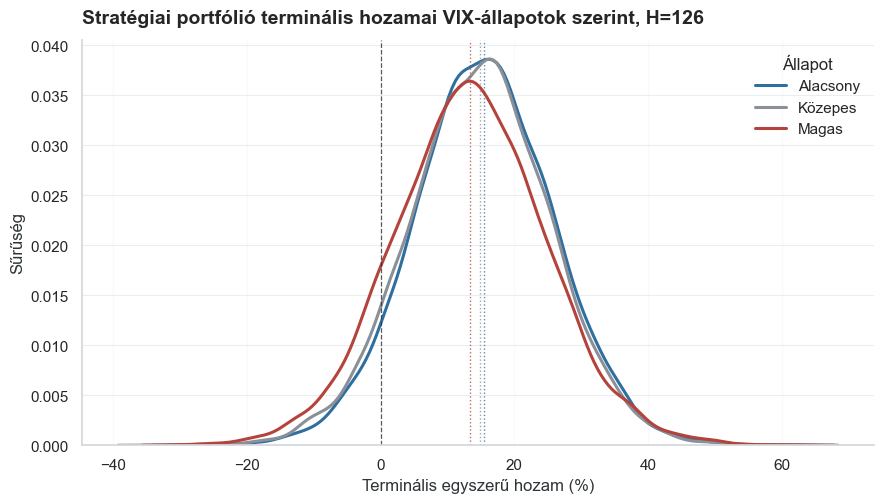

In [29]:
vix = state_raw["VIX"].reindex(strategic_pnl.index).ffill().dropna()
vix_masks = {label: pd.Series(mask, index=vix.index) for label, mask in quantile_state_masks(vix.values).items()}

for horizon in ffr_horizons:
    terminal_vix, state_prob_vix, states_vector_vix, labels_vix = terminal_returns_by_state(
        strategic_pnl, vix, vix_masks, horizon=horizon, num_paths=ffr_num_paths
    )
    display_ffr_diagnostics(f"VIX-állapotok, H={horizon}", terminal_vix, state_prob_vix, labels_vix, states_vector_vix)
    plot_terminal_kde(terminal_vix, f"Stratégiai portfólió terminális hozamai VIX-állapotok szerint, H={horizon}")

## 9. Külön FFR-teszt: VIX határidős struktúra normál / krízis

A krízisállapot jelenleg: `VIX - VIX3M > 0`. Ez a küszöbérték szabadon módosítható paraméter.

VIX term structure állapotok, H=21
EP-diagnosztika


,Megfigyelések,Relatív entrópia,Effektív forgatókönyvek,Effektív forgatókönyvek %
Állapot,,,,
Normál,2033,0.1230,"1,960.4335",0.8843
Krízis,184,1.7639,379.9572,0.1714


Terminális egyszerűhozam-diagnosztika


,Átlaghozam %,Volatilitás %,VaR veszteség %,CVaR veszteség %
Állapot,,,,
Normál,1.7346,4.9031,6.4873,9.4730
Krízis,0.3651,6.2717,10.1890,13.6876


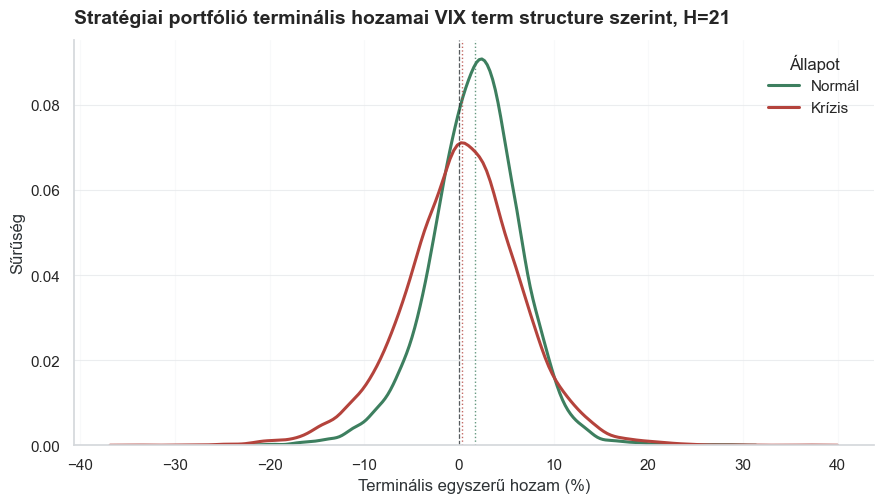

VIX term structure állapotok, H=126
EP-diagnosztika


,Megfigyelések,Relatív entrópia,Effektív forgatókönyvek,Effektív forgatókönyvek %
Állapot,,,,
Normál,2033,0.1230,"1,960.4335",0.8843
Krízis,184,1.7639,379.9572,0.1714


Terminális egyszerűhozam-diagnosztika


,Átlaghozam %,Volatilitás %,VaR veszteség %,CVaR veszteség %
Állapot,,,,
Normál,10.1939,13.3263,11.5396,16.7342
Krízis,8.8647,14.0296,13.0510,18.1811


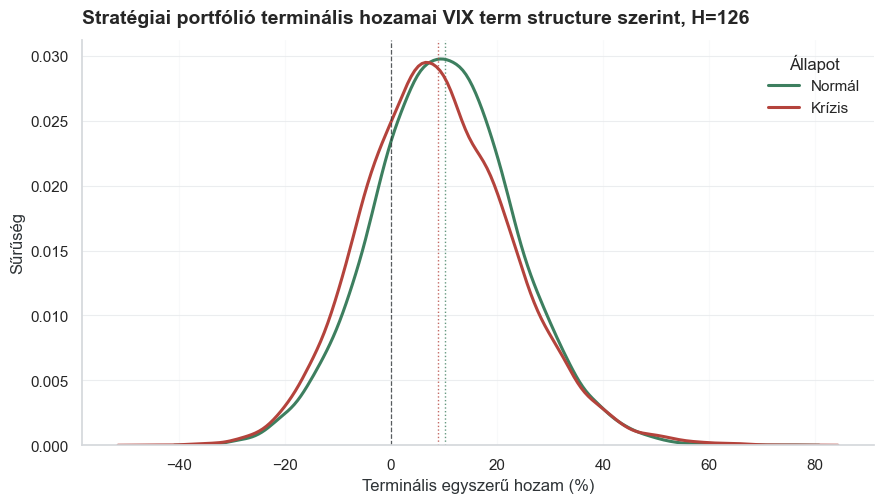

In [30]:
vix_term_threshold = 0.0
vix_term = state_raw["VIX term"].reindex(strategic_pnl.index).ffill().dropna()
term_masks = {
    label: pd.Series(mask, index=vix_term.index)
    for label, mask in binary_state_masks(vix_term.values, threshold=vix_term_threshold).items()
}

for horizon in ffr_horizons:
    terminal_term, state_prob_term, states_vector_term, labels_term = terminal_returns_by_state(
        strategic_pnl, vix_term, term_masks, horizon=horizon, num_paths=ffr_num_paths
    )
    display_ffr_diagnostics(f"VIX term structure állapotok, H={horizon}", terminal_term, state_prob_term, labels_term, states_vector_term)
    plot_terminal_kde(terminal_term, f"Stratégiai portfólió terminális hozamai VIX term structure szerint, H={horizon}")

## 10. Külön FFR-teszt: amerikai 30 éves zérókupon-hozamállapotok

A hozamoknál nem a nyers szint szerinti kosarakat használjuk elsődleges motorként. Az FFR állapotváltozó a 30 éves zérókupon-proxy stacionárius transzformációja, a 15. és 85. percentilis alapján felosztva. Az alacsony állapot kedvezőtlen 30 éves zérókupon-hozamot / emelkedő hozamnyomást, a magas állapot támogató 30 éves zérókupon-hozamot / csökkenő hozamkörnyezetet jelent.

In [ ]:
zcb_30y_chg = state_raw["Amerikai 30 éves zérókupon logváltozás"].reindex(strategic_pnl.index).ffill().dropna()
zcb_masks_raw = quantile_state_masks(zcb_30y_chg.values, low_q=0.15, high_q=0.85)
zcb_masks = {
    "30 éves zérókupon esik / emelkedő hozamnyomás": pd.Series(zcb_masks_raw["Alacsony"], index=zcb_30y_chg.index),
    "30 éves semleges környezet": pd.Series(zcb_masks_raw["Közepes"], index=zcb_30y_chg.index),
    "30 éves zérókupon emelkedik / csökkenő hozamtámogatás": pd.Series(zcb_masks_raw["Magas"], index=zcb_30y_chg.index),
}

for horizon in ffr_horizons:
    terminal_zcb, state_prob_zcb, states_vector_zcb, labels_zcb = terminal_returns_by_state(
        strategic_pnl, zcb_30y_chg, zcb_masks, horizon=horizon, num_paths=ffr_num_paths
    )
    display_ffr_diagnostics(f"30 éves zérókupon-állapotok, H={horizon}", terminal_zcb, state_prob_zcb, labels_zcb, states_vector_zcb)
    plot_terminal_kde(terminal_zcb, f"Stratégiai portfólió terminális hozamai 30 éves zérókupon-állapotok szerint, H={horizon}")

## 11. Együttes Bull / Neutral / Bear FFR-esetek

- Bull: alacsony VIX, normál VIX term structure, támogató 30 éves zérókupon-környezet.
- Neutral: közepes VIX, normál VIX term structure, semleges 30 éves zérókupon-környezet.
- Bear: magas VIX, krízis VIX term structure, kedvezőtlen 30 éves zérókupon-környezet.

Belsőleg szerepel egy `Egyéb` állapot is, hogy minden történelmi megfigyeléshez tartozzon átmeneti állapot, de ezt nem ábrázoljuk.

In [ ]:
joint_state_df = pd.concat(
    [
        vix.rename("VIX"),
        vix_term.rename("VIX term"),
        zcb_30y_chg.rename("30Y ZCB log change"),
    ],
    axis=1,
).dropna()

vix_low = vix_masks["Alacsony"].reindex(joint_state_df.index).fillna(False)
vix_mid = vix_masks["Közepes"].reindex(joint_state_df.index).fillna(False)
vix_high = vix_masks["Magas"].reindex(joint_state_df.index).fillna(False)
term_normal = term_masks["Normál"].reindex(joint_state_df.index).fillna(False)
term_crisis = term_masks["Krízis"].reindex(joint_state_df.index).fillna(False)
zcb_down = zcb_masks["30 éves zérókupon esik / emelkedő hozamnyomás"].reindex(joint_state_df.index).fillna(False)
zcb_neutral = zcb_masks["30 éves semleges környezet"].reindex(joint_state_df.index).fillna(False)
zcb_up = zcb_masks["30 éves zérókupon emelkedik / csökkenő hozamtámogatás"].reindex(joint_state_df.index).fillna(False)

joint_masks_core = {
    "Bull": vix_low & term_normal & zcb_up,
    "Neutral": vix_mid & term_normal & zcb_neutral,
    "Bear": vix_high & term_crisis & zcb_down,
}
assigned = pd.concat(joint_masks_core.values(), axis=1).any(axis=1)
joint_masks = {
    **joint_masks_core,
    "Egyéb": ~assigned,
}

pd.Series({label: int(mask.sum()) for label, mask in joint_masks.items()}, name="Megfigyelések")

Bull         63
Neutral     780
Bear         30
Egyéb      1343
Name: Megfigyelések, dtype: int64

Együttes Bull / Neutral / Bear állapotok, H=21
EP-diagnosztika


,Megfigyelések,Relatív entrópia,Effektív forgatókönyvek,Effektív forgatókönyvek %
Állapot,,,,
Bull,63,3.1438,95.5524,0.0431
Neutral,780,0.8453,951.5690,0.4294
Bear,30,3.1611,93.9138,0.0424
Egyéb,1343,0.0844,"2,036.6706",0.9191


Terminális egyszerűhozam-diagnosztika


,Átlaghozam %,Volatilitás %,VaR veszteség %,CVaR veszteség %
Állapot,,,,
Bull,3.9721,4.3124,3.1857,5.6608
Neutral,3.1532,4.1409,3.5293,5.7524
Bear,1.8877,6.0668,8.1753,11.3417


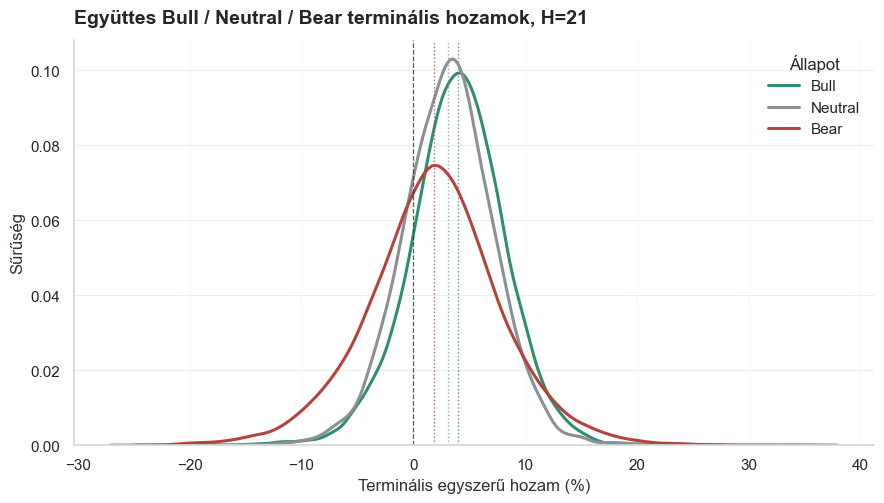

Együttes Bull / Neutral / Bear állapotok, H=126
EP-diagnosztika


,Megfigyelések,Relatív entrópia,Effektív forgatókönyvek,Effektív forgatókönyvek %
Állapot,,,,
Bull,63,3.1438,95.5524,0.0431
Neutral,780,0.8453,951.5690,0.4294
Bear,30,3.1611,93.9138,0.0424
Egyéb,1343,0.0844,"2,036.6706",0.9191


Terminális egyszerűhozam-diagnosztika


,Átlaghozam %,Volatilitás %,VaR veszteség %,CVaR veszteség %
Állapot,,,,
Bull,21.5773,12.3330,-1.8676,2.9509
Neutral,20.5006,12.1977,-1.2178,3.5213
Bear,18.9244,13.2007,1.4833,6.8413


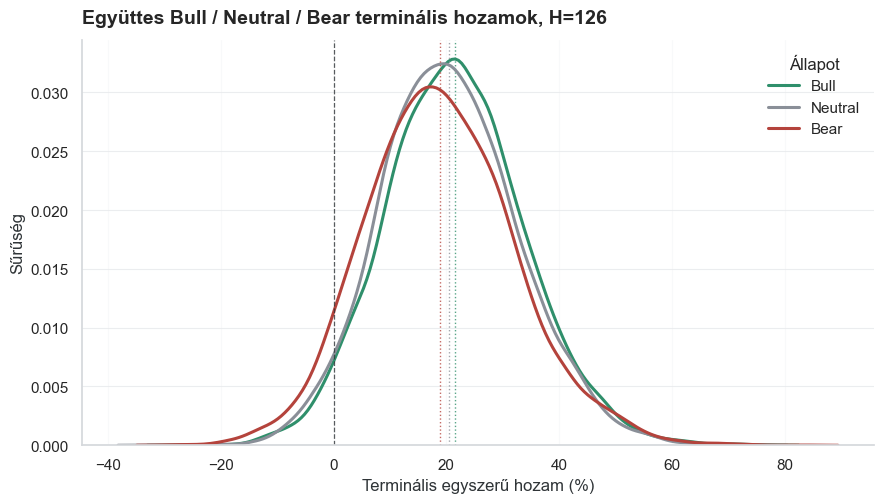

In [ ]:
for horizon in [21, 126]:
    terminal_joint, state_prob_joint, states_vector_joint, labels_joint = terminal_returns_by_joint_state(
        strategic_pnl,
        joint_state_df,
        joint_masks,
        horizon=horizon,
        num_paths=ffr_num_paths,
        labels_to_plot=["Bull", "Neutral", "Bear"],
    )
    display_ffr_diagnostics(f"Együttes Bull / Neutral / Bear állapotok, H={horizon}", terminal_joint, state_prob_joint, labels_joint, states_vector_joint)
    plot_terminal_kde(
        terminal_joint,
        f"Együttes Bull / Neutral / Bear terminális hozamok, H={horizon}",
        save_name=f"04_egyuttes_bull_neutral_bear_H{horizon}",
    )